In [2]:
import pandas as pd
import numpy as np

FEATURES_PATH = "../data/anime_features.csv"

anime_features = pd.read_csv(FEATURES_PATH)

print("Rows:", len(anime_features))
print("Columns:", len(anime_features.columns))

Rows: 16216
Columns: 19


In [3]:
id_columns = [
    "review_count",
    "log_review_count",
    "members",
    "popularity",
    "score",
    "avg_review_score",
    "score_std"
]

anime_features[id_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
review_count,16216.0,8.048779,33.699166,0.00,0.000000,1.000000,3.000000,1.292000e+03
log_review_count,16216.0,0.919506,1.245513,0.00,0.000000,0.693147,1.386294,7.164720e+00
members,16216.0,27591.894549,93882.505758,25.00,292.000000,1839.500000,11600.000000,1.871043e+06
popularity,16216.0,8161.171621,4714.317489,1.00,4082.000000,8158.500000,12243.250000,1.633800e+04
score,15875.0,6.346466,0.972700,1.25,5.700000,6.370000,7.040000,9.230000e+00
avg_review_score,8113.0,6.765124,1.717949,1.00,6.000000,7.000000,8.000000,1.000000e+01
score_std,5870.0,1.798571,0.874860,0.00,1.272005,1.787301,2.280351,6.363961e+00


In [4]:
momentum_threshold = anime_features["log_review_count"].quantile(0.75)

review_threshold = np.expm1(momentum_threshold)

print(f"75th percentile of log review count: {momentum_threshold:.3f}")
print(f"Equivalent review count: {review_threshold:.1f}")

75th percentile of log review count: 1.386
Equivalent review count: 3.0


In [5]:
model_df = anime_features[
    anime_features["review_count"] >= 10
].copy()

print("Anime in modeling population:", len(model_df))
print()
print(model_df["review_count"].describe())

Anime in modeling population: 2266

count    2266.000000
mean       50.253310
std        77.678129
min        10.000000
25%        16.000000
50%        25.000000
75%        50.000000
max      1292.000000
Name: review_count, dtype: float64


In [6]:
momentum_threshold = model_df["review_count"].quantile(0.75)

print(f"75th percentile review count: {momentum_threshold:.2f}")
print(
    "Number of anime above threshold:",
    (model_df["review_count"] > momentum_threshold).sum()
)

75th percentile review count: 50.00
Number of anime above threshold: 557


In [7]:
model_df["high_momentum"] = (
    model_df["review_count"] > momentum_threshold
).astype(int)

print(model_df["high_momentum"].value_counts())
print()
print(model_df["high_momentum"].value_counts(normalize=True))

high_momentum
0    1709
1     557
Name: count, dtype: int64

high_momentum
0    0.754192
1    0.245808
Name: proportion, dtype: float64


In [8]:
feature_columns = [
    "members",
    "popularity",
    "score",
    "avg_review_score",
    "score_std",
    "score_difference",
    "abs_score_difference"
]

X = model_df[feature_columns].copy()
y = model_df["high_momentum"].copy()

print("Features:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['members', 'popularity', 'score', 'avg_review_score', 'score_std', 'score_difference', 'abs_score_difference']

X shape: (2266, 7)
y shape: (2266,)


In [9]:
missing_val=X.isna().sum()
print(missing_val)

members                 0
popularity              0
score                   0
avg_review_score        0
score_std               0
score_difference        0
abs_score_difference    0
dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 1812
Testing samples: 454

Training target distribution:
high_momentum
0    0.754415
1    0.245585
Name: proportion, dtype: float64

Testing target distribution:
high_momentum
0    0.753304
1    0.246696
Name: proportion, dtype: float64


In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline accuracy: {baseline_accuracy:.3f}")

Baseline accuracy: 0.753


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]
logistic_auc = roc_auc_score(y_test, logistic_probabilities)

print(f"Accuracy:  {logistic_accuracy:.3f}")
print(f"Precision: {logistic_precision:.3f}")
print(f"Recall:    {logistic_recall:.3f}")
print(f"F1 Score:  {logistic_f1:.3f}")
print(f"ROC-AUC:   {logistic_auc:.3f}")

Accuracy:  0.863
Precision: 0.745
Recall:    0.679
F1 Score:  0.710
ROC-AUC:   0.910


[[316  26]
 [ 36  76]]


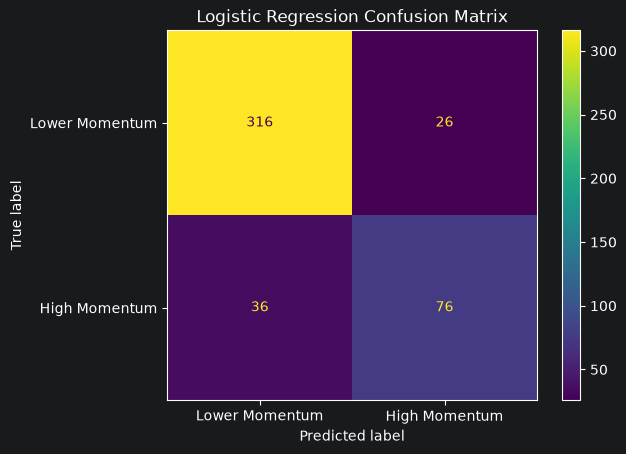

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, logistic_predictions)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Lower Momentum", "High Momentum"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [15]:
coefficients = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": logistic_model.named_steps["model"].coef_[0]
})

coefficients["absolute_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients.sort_values(
    "absolute_coefficient",
    ascending=False
)

,feature,coefficient,absolute_coefficient
1,popularity,-3.517303,3.517303
5,score_difference,0.675058,0.675058
2,score,-0.550139,0.550139
4,score_std,0.525516,0.525516
0,members,0.397106,0.397106
6,abs_score_difference,-0.181155,0.181155
3,avg_review_score,0.028514,0.028514


In [16]:
X.corr().round(2)

,members,popularity,score,avg_review_score,score_std,score_difference,abs_score_difference
members,1.00,-0.61,0.41,0.21,-0.04,-0.11,-0.07
popularity,-0.61,1.00,-0.55,-0.30,0.13,0.12,0.14
score,0.41,-0.55,1.00,0.80,-0.42,0.18,-0.25
avg_review_score,0.21,-0.30,0.80,1.00,-0.58,0.74,-0.48
score_std,-0.04,0.13,-0.42,-0.58,1.00,-0.48,0.23
score_difference,-0.11,0.12,0.18,0.74,-0.48,1.00,-0.50
abs_score_difference,-0.07,0.14,-0.25,-0.48,0.23,-0.50,1.00


In [17]:
feature_columns_clean = [
    "members",
    "popularity",
    "score"
]

X_clean = model_df[feature_columns_clean].copy()
y = model_df["high_momentum"].copy()

print("Features used for modeling:")
print(X_clean.columns.tolist())

print("\nX shape:", X_clean.shape)
print("y shape:", y.shape)

Features used for modeling:
['members', 'popularity', 'score']

X shape: (2266, 3)
y shape: (2266,)


In [18]:
X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_clean))
print("Testing samples:", len(X_test_clean))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 1812
Testing samples: 454

Training target distribution:
high_momentum
0    0.754415
1    0.245585
Name: proportion, dtype: float64

Testing target distribution:
high_momentum
0    0.753304
1    0.246696
Name: proportion, dtype: float64


In [19]:
logistic_clean = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

logistic_clean.fit(X_train_clean, y_train)

clean_predictions = logistic_clean.predict(X_test_clean)
clean_probabilities = logistic_clean.predict_proba(X_test_clean)[:, 1]

print("Clean Logistic Regression trained successfully.")

Clean Logistic Regression trained successfully.


In [20]:
clean_accuracy = accuracy_score(y_test, clean_predictions)
clean_precision = precision_score(y_test, clean_predictions)
clean_recall = recall_score(y_test, clean_predictions)
clean_f1 = f1_score(y_test, clean_predictions)
clean_auc = roc_auc_score(y_test, clean_probabilities)

print(f"Accuracy:  {clean_accuracy:.3f}")
print(f"Precision: {clean_precision:.3f}")
print(f"Recall:    {clean_recall:.3f}")
print(f"F1 Score:  {clean_f1:.3f}")
print(f"ROC-AUC:   {clean_auc:.3f}")

Accuracy:  0.848
Precision: 0.705
Recall:    0.661
F1 Score:  0.682
ROC-AUC:   0.904


In [21]:
model_results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        clean_accuracy
    ],
    "Precision": [
        np.nan,
        clean_precision
    ],
    "Recall": [
        np.nan,
        clean_recall
    ],
    "F1": [
        np.nan,
        clean_f1
    ],
    "ROC-AUC": [
        np.nan,
        clean_auc
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Majority Baseline,0.753304,NaN,NaN,NaN,NaN
1,Logistic Regression,0.848018,0.704762,0.660714,0.682028,0.904449


In [22]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(X_train_clean, y_train)

rf_predictions = random_forest.predict(X_test_clean)
rf_probabilities = random_forest.predict_proba(X_test_clean)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [23]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_auc = roc_auc_score(y_test, rf_probabilities)

print(f"Accuracy:  {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall:    {rf_recall:.3f}")
print(f"F1 Score:  {rf_f1:.3f}")
print(f"ROC-AUC:   {rf_auc:.3f}")

Accuracy:  0.813
Precision: 0.596
Recall:    0.750
F1 Score:  0.664
ROC-AUC:   0.877


In [24]:
model_results.loc[len(model_results)] = [
    "Random Forest",
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_auc
]

model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Majority Baseline,0.753304,NaN,NaN,NaN,NaN
1,Logistic Regression,0.848018,0.704762,0.660714,0.682028,0.904449
2,Random Forest,0.812775,0.595745,0.750000,0.664032,0.876619


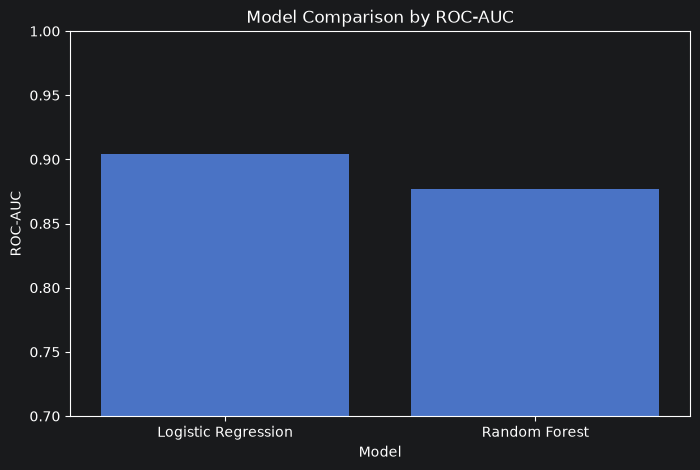

In [33]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_results.dropna(subset=["ROC-AUC"]),
    x="Model",
    y="ROC-AUC"
)

plt.ylim(0.7, 1.0)
plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("Model Comparison by ROC-AUC")
plt.show()

In [34]:
clean_coefficients = pd.DataFrame({
    "feature": feature_columns_clean,
    "coefficient": logistic_clean.named_steps["model"].coef_[0]
})

clean_coefficients["absolute_coefficient"] = (
    clean_coefficients["coefficient"].abs()
)

clean_coefficients.sort_values(
    "absolute_coefficient",
    ascending=False
)

,feature,coefficient,absolute_coefficient
1,popularity,-3.195180,3.195180
2,score,-0.453533,0.453533
0,members,0.358044,0.358044


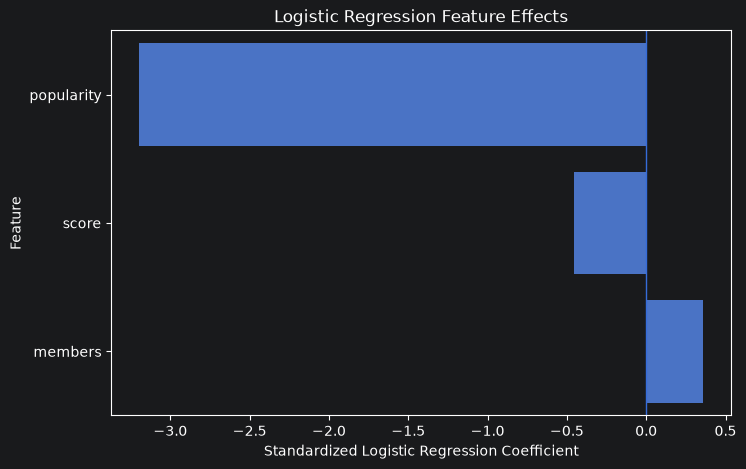

In [35]:
clean_coefficients_sorted = (
    clean_coefficients
    .sort_values("coefficient")
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=clean_coefficients_sorted,
    x="coefficient",
    y="feature"
)

plt.xlabel("Standardized Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Effects")
plt.axvline(0, linewidth=1)
plt.show()

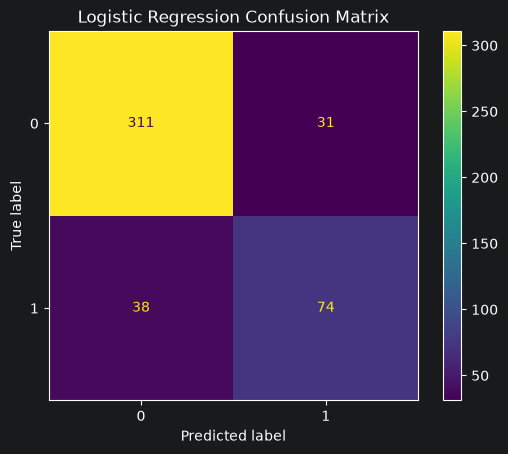

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    clean_predictions
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

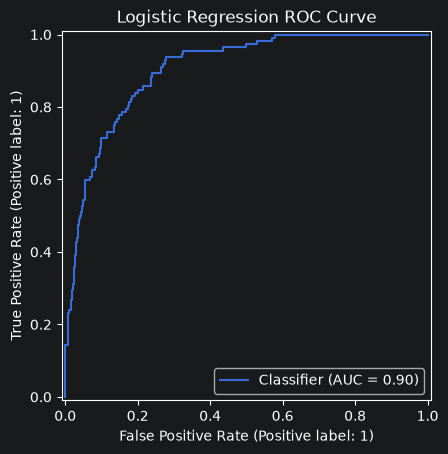

In [37]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    clean_probabilities
)

plt.title("Logistic Regression ROC Curve")
plt.show()

In [38]:
final_model = logistic_clean

print("Final model: Logistic Regression")
print(f"ROC-AUC: {clean_auc:.3f}")
print(f"F1 Score: {clean_f1:.3f}")
print(f"Accuracy: {clean_accuracy:.3f}")

Final model: Logistic Regression
ROC-AUC: 0.904
F1 Score: 0.682
Accuracy: 0.848


In [39]:
import joblib

MODEL_PATH = "../outputs/models/logistic_momentum_model.pkl"

joblib.dump(final_model, MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: ../outputs/models/logistic_momentum_model.pkl


In [40]:
final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        clean_accuracy,
        clean_precision,
        clean_recall,
        clean_f1,
        clean_auc
    ]
})

final_summary

,Metric,Value
0,Accuracy,0.848018
1,Precision,0.704762
2,Recall,0.660714
3,F1 Score,0.682028
4,ROC-AUC,0.904449


In [41]:
RESULTS_PATH = "../outputs/tables/model_results.csv"

model_results.to_csv(RESULTS_PATH, index=False)

print(f"Results saved to: {RESULTS_PATH}")

Results saved to: ../outputs/tables/model_results.csv


In [42]:
hidden_momentum_df = model_df[
    ["uid", "title", "members", "popularity", "score", "review_count", "log_review_count"]
].copy()

hidden_momentum_df.head()

,uid,title,members,popularity,score,review_count,log_review_count
0,28891,Haikyuu!! Second Season,489888,141,8.82,52.0,3.970292
1,23273,Shigatsu wa Kimi no Uso,995473,28,8.83,20.0,3.044522
2,34599,Made in Abyss,581663,98,8.83,305.0,5.723585
3,5114,Fullmetal Alchemist: Brotherhood,1615084,4,9.23,637.0,6.458338
4,31758,Kizumonogatari III: Reiketsu-hen,214621,502,8.83,28.0,3.367296


In [43]:
from sklearn.model_selection import train_test_split

hidden_feature_columns = [
    "members",
    "popularity",
    "score"
]

X_hidden = hidden_momentum_df[hidden_feature_columns]
y_hidden = hidden_momentum_df["log_review_count"]

X_hidden_train, X_hidden_test, y_hidden_train, y_hidden_test = train_test_split(
    X_hidden,
    y_hidden,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_hidden_train))
print("Test rows:", len(X_hidden_test))

Training rows: 1812
Test rows: 454


In [44]:
from sklearn.linear_model import LinearRegression

hidden_model = LinearRegression()

hidden_model.fit(
    X_hidden_train,
    y_hidden_train
)

hidden_predictions = hidden_model.predict(X_hidden_test)

print("Hidden momentum regression model trained successfully.")

Hidden momentum regression model trained successfully.


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

hidden_mae = mean_absolute_error(
    y_hidden_test,
    hidden_predictions
)

hidden_rmse = np.sqrt(
    mean_squared_error(
        y_hidden_test,
        hidden_predictions
    )
)

hidden_r2 = r2_score(
    y_hidden_test,
    hidden_predictions
)

print(f"MAE:  {hidden_mae:.3f}")
print(f"RMSE: {hidden_rmse:.3f}")
print(f"R²:   {hidden_r2:.3f}")

MAE:  0.413
RMSE: 0.523
R²:   0.628


In [46]:
hidden_test_results = hidden_momentum_df.loc[
    X_hidden_test.index,
    ["uid", "title", "members", "popularity", "score", "review_count", "log_review_count"]
].copy()

hidden_test_results["predicted_log_reviews"] = hidden_predictions

hidden_test_results["momentum_residual"] = (
    hidden_test_results["log_review_count"]
    - hidden_test_results["predicted_log_reviews"]
)

hidden_test_results.sort_values(
    "momentum_residual",
    ascending=False
).head(10)

,uid,title,members,popularity,score,review_count,log_review_count,predicted_log_reviews,momentum_residual
421,721,Princess Tutu,110983,1010,8.16,94.0,4.553877,3.344621,1.209255
394,25013,Akatsuki no Yona,441757,174,8.13,239.0,5.480639,4.354583,1.126056
691,37965,Kaze ga Tsuyoku Fuiteiru,118998,955,8.49,84.0,4.442651,3.322494,1.120158
778,34798,Yuru Camp△,209936,521,8.31,122.0,4.812184,3.696297,1.115887
243,10721,Mawaru Penguindrum,221240,482,8.01,127.0,4.852030,3.786483,1.065547
2748,1639,Boku no Pico,97619,1122,4.85,136.0,4.919981,3.857666,1.062315
706,37208,Mo Dao Zu Shi,76350,1418,8.53,60.0,4.110874,3.070954,1.039919
387,2034,Lovely★Complex,356826,259,8.13,176.0,5.176150,4.138584,1.037566
301,5682,Phantom: Requiem for the Phantom,235408,436,8.06,127.0,4.852030,3.824072,1.027958
659,5941,Cross Game,86377,1252,8.43,65.0,4.189655,3.164441,1.025214


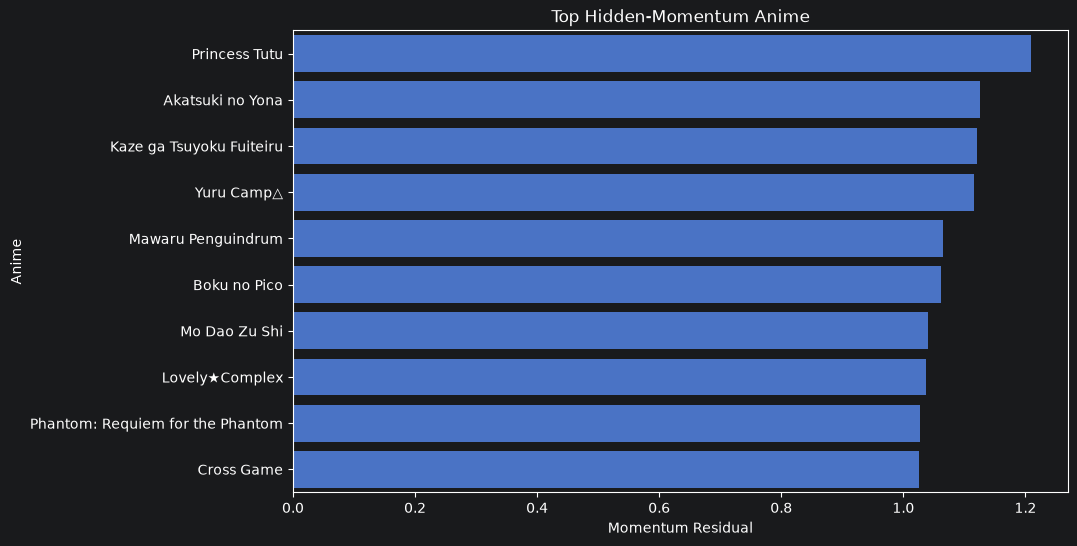

In [47]:
top_hidden_momentum = (
    hidden_test_results
    .sort_values("momentum_residual", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_hidden_momentum,
    x="momentum_residual",
    y="title"
)

plt.xlabel("Momentum Residual")
plt.ylabel("Anime")
plt.title("Top Hidden-Momentum Anime")
plt.show()

In [48]:
HIDDEN_PATH = "../outputs/tables/hidden_momentum_candidates.csv"

top_hidden_momentum.to_csv(
    HIDDEN_PATH,
    index=False
)

print(f"Candidates saved to: {HIDDEN_PATH}")

Candidates saved to: ../outputs/tables/hidden_momentum_candidates.csv


In [49]:
top_hidden_momentum[
    [
        "title",
        "members",
        "popularity",
        "score",
        "review_count",
        "predicted_log_reviews",
        "momentum_residual"
    ]
]

,title,members,popularity,score,review_count,predicted_log_reviews,momentum_residual
421,Princess Tutu,110983,1010,8.16,94.0,3.344621,1.209255
394,Akatsuki no Yona,441757,174,8.13,239.0,4.354583,1.126056
691,Kaze ga Tsuyoku Fuiteiru,118998,955,8.49,84.0,3.322494,1.120158
778,Yuru Camp△,209936,521,8.31,122.0,3.696297,1.115887
243,Mawaru Penguindrum,221240,482,8.01,127.0,3.786483,1.065547
2748,Boku no Pico,97619,1122,4.85,136.0,3.857666,1.062315
706,Mo Dao Zu Shi,76350,1418,8.53,60.0,3.070954,1.039919
387,Lovely★Complex,356826,259,8.13,176.0,4.138584,1.037566
301,Phantom: Requiem for the Phantom,235408,436,8.06,127.0,3.824072,1.027958
659,Cross Game,86377,1252,8.43,65.0,3.164441,1.025214


In [50]:
hidden_test_results["predicted_reviews"] = (
    np.expm1(hidden_test_results["predicted_log_reviews"])
)

hidden_test_results[
    [
        "title",
        "review_count",
        "predicted_reviews",
        "momentum_residual"
    ]
].sort_values(
    "momentum_residual",
    ascending=False
).head(10)

,title,review_count,predicted_reviews,momentum_residual
421,Princess Tutu,94.0,27.349843,1.209255
394,Akatsuki no Yona,239.0,76.834337,1.126056
691,Kaze ga Tsuyoku Fuiteiru,84.0,26.729408,1.120158
778,Yuru Camp△,122.0,39.297811,1.115887
243,Mawaru Penguindrum,127.0,43.101042,1.065547
2748,Boku no Pico,136.0,46.354709,1.062315
706,Mo Dao Zu Shi,60.0,20.562472,1.039919
387,Lovely★Complex,176.0,61.713968,1.037566
301,Phantom: Requiem for the Phantom,127.0,44.790293,1.027958
659,Cross Game,65.0,22.675500,1.025214


In [51]:
acquisition_candidates = (
    hidden_test_results
    .sort_values("momentum_residual", ascending=False)
    .head(10)
    [
        [
            "uid",
            "title",
            "members",
            "popularity",
            "score",
            "review_count",
            "predicted_reviews",
            "momentum_residual"
        ]
    ]
    .copy()
)

acquisition_candidates

,uid,title,members,popularity,score,review_count,predicted_reviews,momentum_residual
421,721,Princess Tutu,110983,1010,8.16,94.0,27.349843,1.209255
394,25013,Akatsuki no Yona,441757,174,8.13,239.0,76.834337,1.126056
691,37965,Kaze ga Tsuyoku Fuiteiru,118998,955,8.49,84.0,26.729408,1.120158
778,34798,Yuru Camp△,209936,521,8.31,122.0,39.297811,1.115887
243,10721,Mawaru Penguindrum,221240,482,8.01,127.0,43.101042,1.065547
2748,1639,Boku no Pico,97619,1122,4.85,136.0,46.354709,1.062315
706,37208,Mo Dao Zu Shi,76350,1418,8.53,60.0,20.562472,1.039919
387,2034,Lovely★Complex,356826,259,8.13,176.0,61.713968,1.037566
301,5682,Phantom: Requiem for the Phantom,235408,436,8.06,127.0,44.790293,1.027958
659,5941,Cross Game,86377,1252,8.43,65.0,22.675500,1.025214


In [52]:
ACQUISITION_PATH = "../outputs/tables/acquisition_candidates.csv"

acquisition_candidates.to_csv(
    ACQUISITION_PATH,
    index=False
)

print(f"Acquisition shortlist saved to: {ACQUISITION_PATH}")

Acquisition shortlist saved to: ../outputs/tables/acquisition_candidates.csv


In [53]:
SUMMARY_PATH = "../outputs/tables/final_model_summary.csv"

final_summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print(f"Final model summary saved to: {SUMMARY_PATH}")

Final model summary saved to: ../outputs/tables/final_model_summary.csv


## Final Modeling Conclusions

The classification analysis shows that Logistic Regression was the strongest model among the tested approaches. It achieved an ROC-AUC of 0.904, with an accuracy of 0.848, precision of 0.705, recall of 0.661, and F1 score of 0.682 on the held-out test set. It substantially outperformed the majority-class baseline (accuracy 0.753) and also outperformed the Random Forest model on ROC-AUC and F1 score.

The model used only existing audience and popularity signals (`members`, `popularity`, and `score`) rather than review-derived variables. This reduces circularity because the target itself is based on review volume. The results suggest that these existing signals contain substantial information about which anime have relatively strong community engagement.

A separate regression analysis was used to identify "above-expected community engagement." The regression model explained 62.8% of the variation in log review count (R² = 0.628). Anime with positive residuals received more community engagement than expected given their audience size, popularity rank, and score. These titles form a screening shortlist for further investigation rather than guaranteed acquisition or streaming recommendations.

### Business Interpretation

The analysis can support an initial IP-acquisition screening process by highlighting anime with strong community momentum and identifying titles that appear to generate unusually high engagement relative to their existing audience signals.

However, the dataset is a cross-sectional MyAnimeList snapshot, so the models should not be interpreted as causal or as guaranteed predictions of future streaming success. Real acquisition decisions would also require licensing availability, acquisition cost, geographic rights, target demographics, competitive positioning, content suitability, and franchise potential.